Purpose: Similar to `bppc_profile_by_physiology.ipynb`, plot expression profiles for other CAM gene families by physiology of *Y. gloriosa.*<br>
Author: Anna Pardo<br>
Date initiated: Mar. 18, 2026

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

In [3]:
# load CAM gene annotation
cam = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",sep="\t",header="infer")

In [4]:
# load TPM data
mdtpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")
mdtpm.head()

/tmp/ipykernel_978/3198679925.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  mdtpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")


,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095122m.g,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g
0,Y1,18,1.0,W,1.0,gloriosa,34.002815,4.546167,0.0,17.236119,...,0.000000,6.167441,1.435253,0.279077,11.420139,0.662252,1.886709,6.675105,0.0,0.000000
1,Y10,2AB,1.5,W,3.0,gloriosa,40.070758,3.628454,0.0,14.918115,...,0.713535,2.197522,15.695904,1.193256,10.172780,0.000000,2.214483,12.125756,0.0,0.000000
2,Y100,2AB,6.5,W,23.0,gloriosa,47.402599,5.201760,0.0,17.406497,...,0.314746,2.261806,21.742515,1.798380,10.256681,1.748663,2.075757,25.215640,0.0,1.838780
3,Y101,2AB,1.0,D,1.0,gloriosa,57.062380,6.374324,0.0,10.567561,...,0.000000,1.072366,27.573939,1.164591,9.105769,1.257431,2.431447,4.508369,0.0,0.813682
4,Y103,2AB,1.0,D,1.0,gloriosa,34.679279,6.087451,0.0,11.115252,...,0.000000,0.914550,28.621412,0.869052,7.076224,0.515567,2.419222,4.625880,0.0,0.867418


In [5]:
mdtpm["genotype"] = mdtpm["genotype"].astype(str)
mdtpm["genotype"].unique()

array(['18', '2AB', '1AB', '19', '15', 'Eudy', 'G', '56', '36', '13',
       '45', '52', '43', '37', '48', '55', '70', '61', '51', '46', '53',
       '16', '6', '12', '20', '50'], dtype=object)

In [6]:
# subset by ZT (every 4 hours)
zttpm = mdtpm[mdtpm["ZT"].isin([1.0,5.0,9.0,13.0,17.0,21.0])]

In [11]:
physcat = json.load(open("/home/leviathan22/Yucca_genomics/phys_figures/physiological_CAM_categories.json"))

In [33]:
def plottpm_genefamily(tpm,genefam,sg=True,camdf=cam):
    camfam = camdf[camdf["gene_abbr"]==genefam]
    csgd = {}
    for i in range(len(camfam.index)):
        csgd[camfam.iloc[i,0]] = camfam.iloc[i,6]
    cgenes = [i for i in list(camfam["GeneID"].unique()) if i in tpm.columns]
    cols = ["sample_name","genotype","treat","ZT"]+cgenes
    pwide = tpm[cols]
    plong = pd.melt(pwide,id_vars=["sample_name","genotype","treat","ZT"],value_vars=cgenes)
    plong = plong.rename(columns={"variable":"GeneID","value":"TPM"}).sort_values(by="treat",ascending=False)
    # add subgenome column if sg=True
    if sg==True:
        plong["subgenome"] = plong["GeneID"].map(csgd)
        # add physiology column
        plong["CAM physiology"] = plong["genotype"].map(physcat)
        return plong.sort_values(by=["treat","subgenome"],ascending=False)
    else:
        return plong.sort_values(by="treat",ascending=False)

In [13]:
def rename_camgenes(gftpm,genefam):
    cgdict = cam[cam["gene_abbr"]==genefam][["GeneID","gene_abbr_unique"]].set_index("GeneID").to_dict()["gene_abbr_unique"]
    gftpm["genename"] = gftpm["GeneID"].map(cgdict)
    return gftpm

In [23]:
# reworked plot_profile() function - to plot profiles by subgenome as well as treatment
def plot_profile(fam,cpdf,axc,a,tf,titletext="Gene Family: ",log=False):
    # pull max TPM (out of curiosity)
    #maxtpm = int(round(max(cpdf["TPM"]),0))
    
    # where axc=either a single value or a tuple
    t = np.arange(0,25)
    xthresh = 12
    
    # convert to logTPM if log=True
    if log==True:
        cpdf["logTPM"] = np.log1p(cpdf["TPM"])
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="logTPM",hue="treat",style="subgenome")
    else:
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="TPM",hue="treat",style="subgenome")
    
    #lim = a[axc].get_ylim()[1]
    a[axc].fill_between(t,0,1,where=t>=xthresh,color="gray",alpha=0.3,transform=a[axc].get_xaxis_transform())
    #a[axc].set_ylim(0,lim)
    
    a[axc].set_xlim(0,24)
    a[axc].tick_params(axis="both",which="major",labelsize=18)
    a[axc].set_xticks(ticks=list(cpdf["ZT"].unique()))
    a[axc].set_xlabel("")
    a[axc].set_ylabel("TPM from uniquely mapped reads",fontsize=18)
    #a[axc].set_title(titletext+fam+" (max TPM: "+str(maxtpm)+")",fontsize=tf)
    a[axc].set_title(titletext+fam,fontsize=tf)
    #plt.rcParams["legend.title_fontsize"] = 16
    #plt.rcParams["legend.fontsize"] = 16
    plt.legend(fontsize=16)

In [24]:
def plot_genefam(genefam):
    # get plotting TPM
    gftpm = plottpm_genefamily(zttpm,genefam)
    gftpm = rename_camgenes(gftpm,genefam)
    
    # subset data by physiology
    c3 = gftpm[gftpm["CAM physiology"]=="C3"]
    c3gt = len(c3["genotype"].unique())
    pfc = gftpm[gftpm["CAM physiology"]=="possible_fac_CAM"]
    pfcgt = len(pfc["genotype"].unique())
    fc = gftpm[gftpm["CAM physiology"]=="facultative_CAM"]
    fcgt = len(fc["genotype"].unique())
    
    fig, ax = plt.subplots(nrows=1,ncols=3,figsize=(30,10),sharey=True)
    plot_profile("C3 genotypes (n="+str(c3gt)+")",c3,0,ax,26,"")
    plot_profile("possibly facultative CAM genotypes (n="+str(pfcgt)+")",pfc,1,ax,24,"")
    plot_profile("facultative CAM genotypes (n="+str(fcgt)+")",fc,2,ax,26,"")
    ylims = [a.get_ylim()[1] for a in ax]
    ymax = max(ylims)
    for a in ax:
        a.set_ylim(0, ymax)

    fig.tight_layout()

    plt.savefig("./allgt_"+genefam+"_profiles_byphys.png",dpi=200,bbox_inches="tight")
    plt.savefig("./allgt_"+genefam+"_profiles_byphys.pdf",dpi=200,bbox_inches="tight")
    plt.savefig("./allgt_"+genefam+"_profiles_byphys.svg",dpi=200,bbox_inches="tight")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


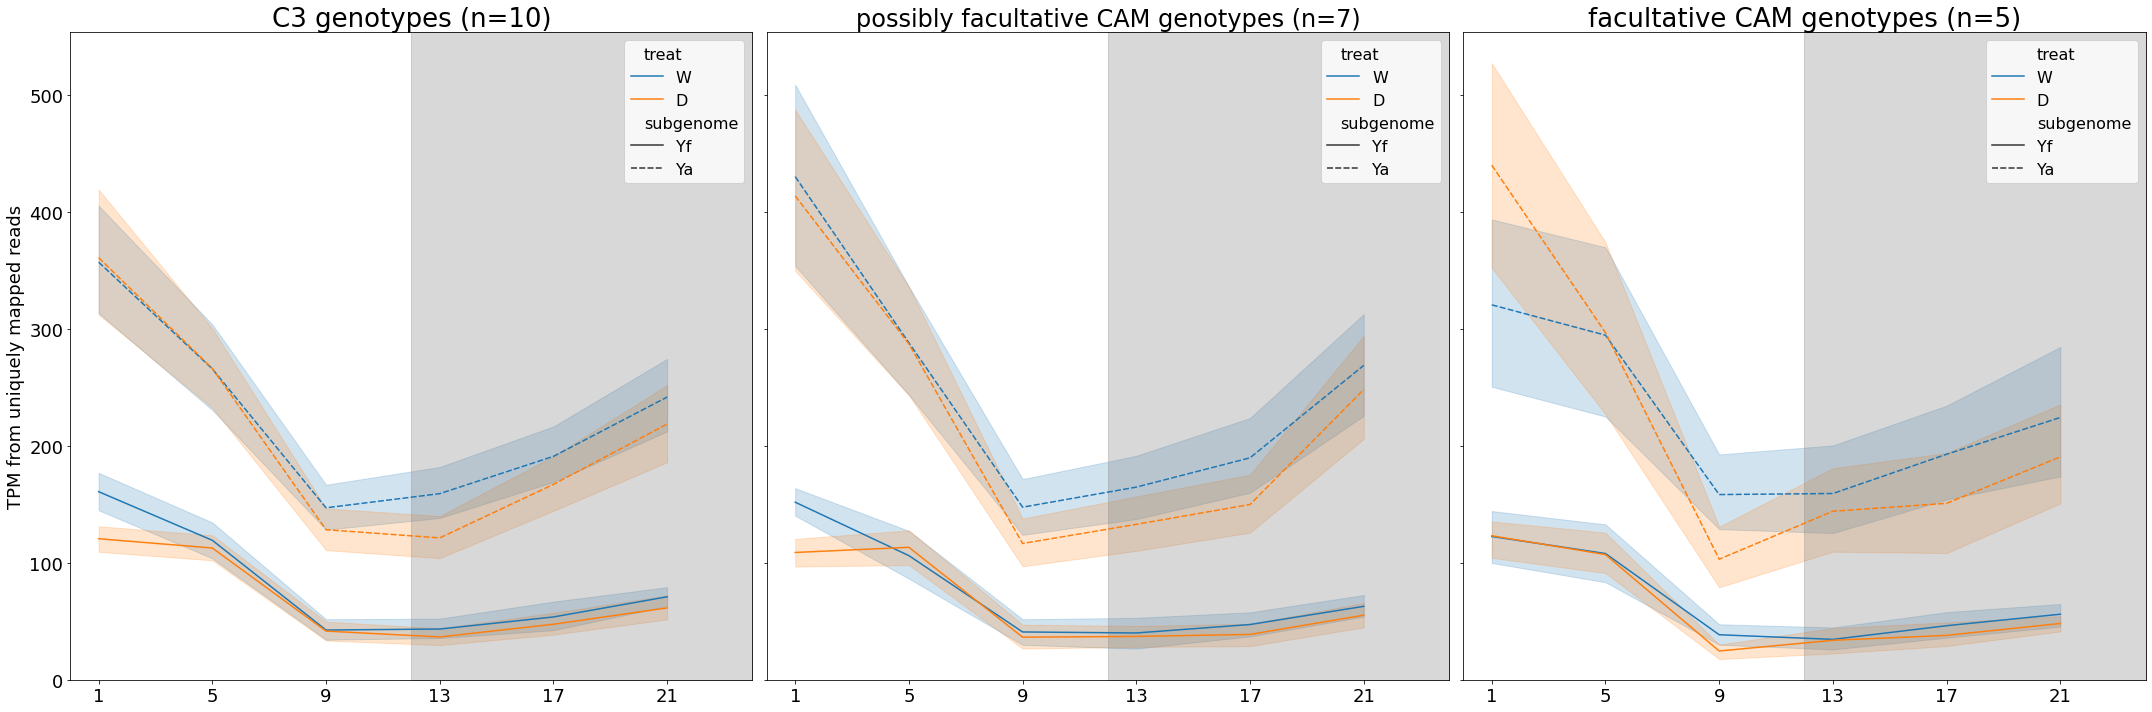

In [25]:
plot_genefam("PPDK")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

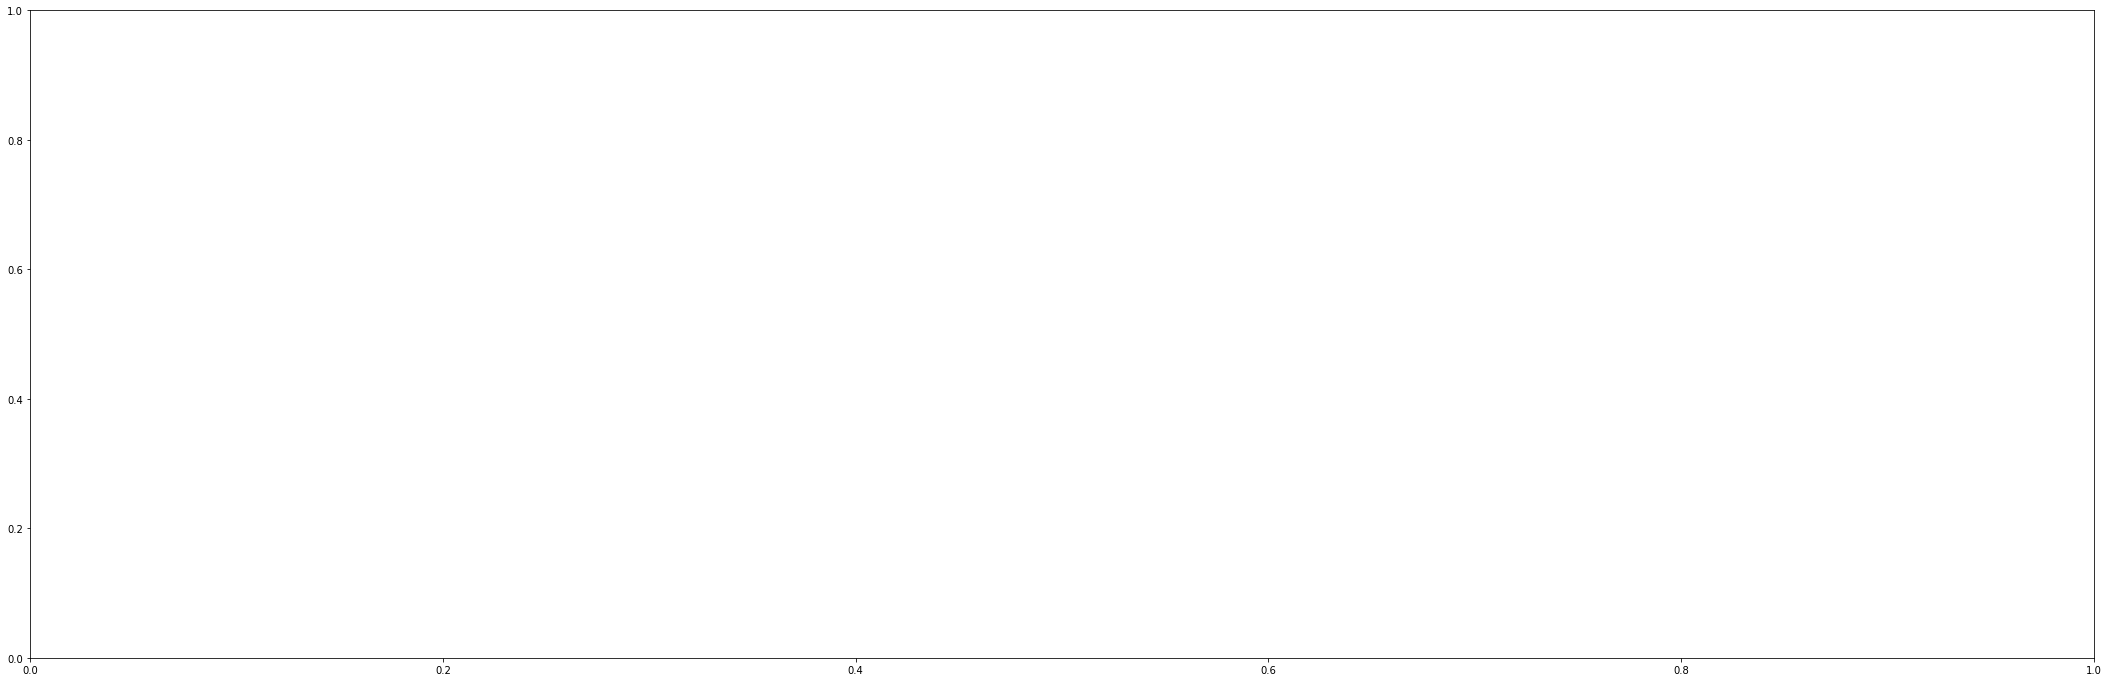

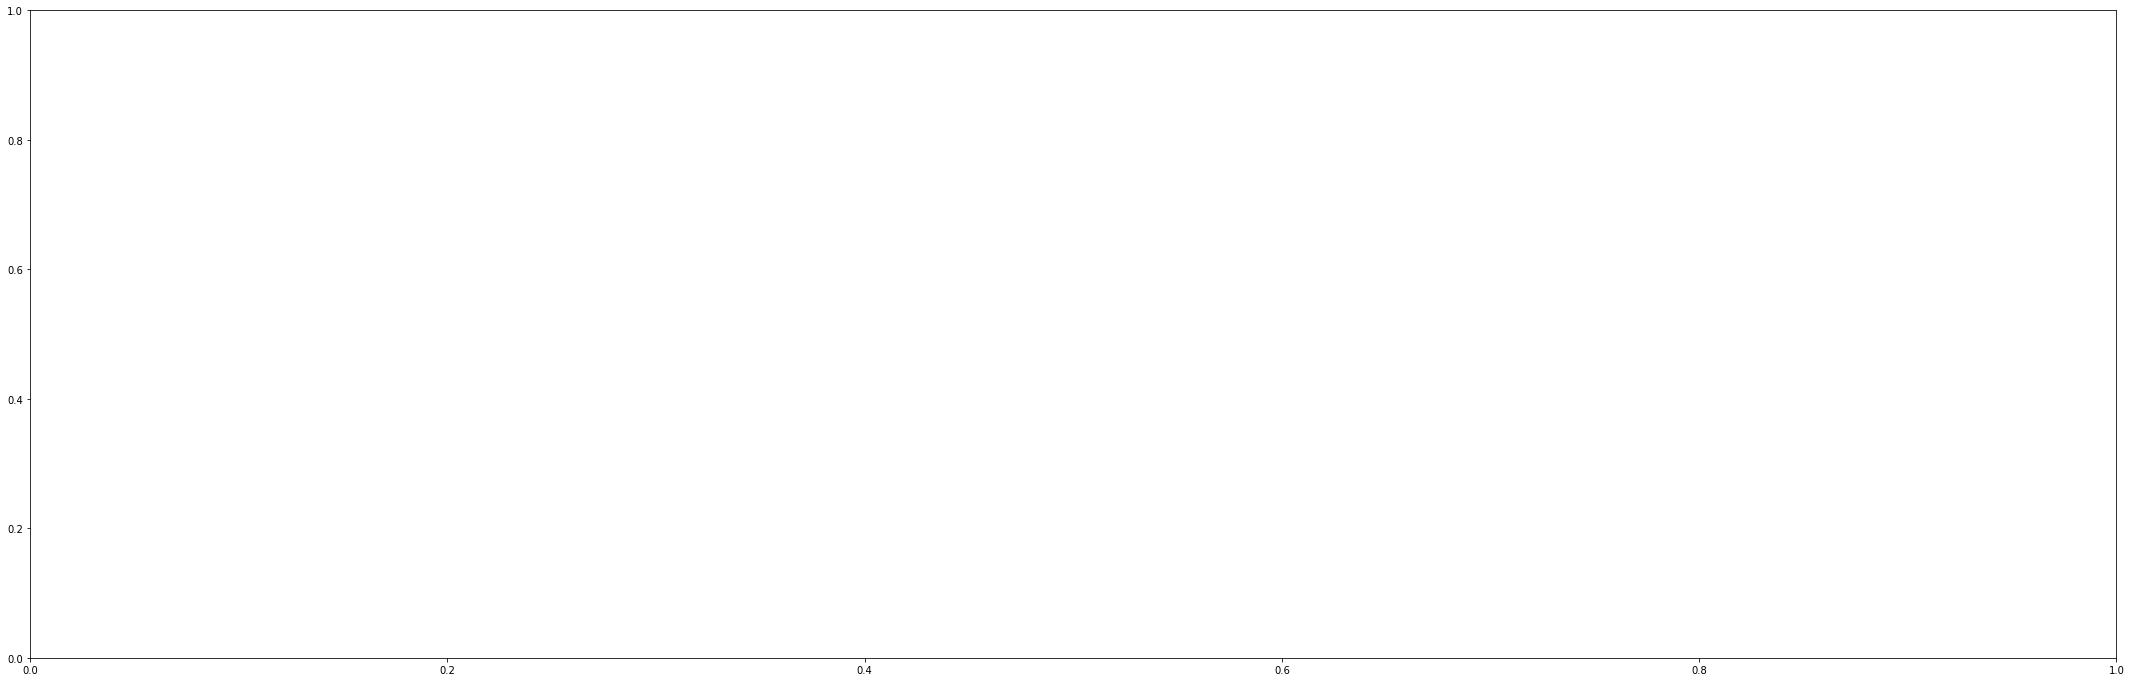

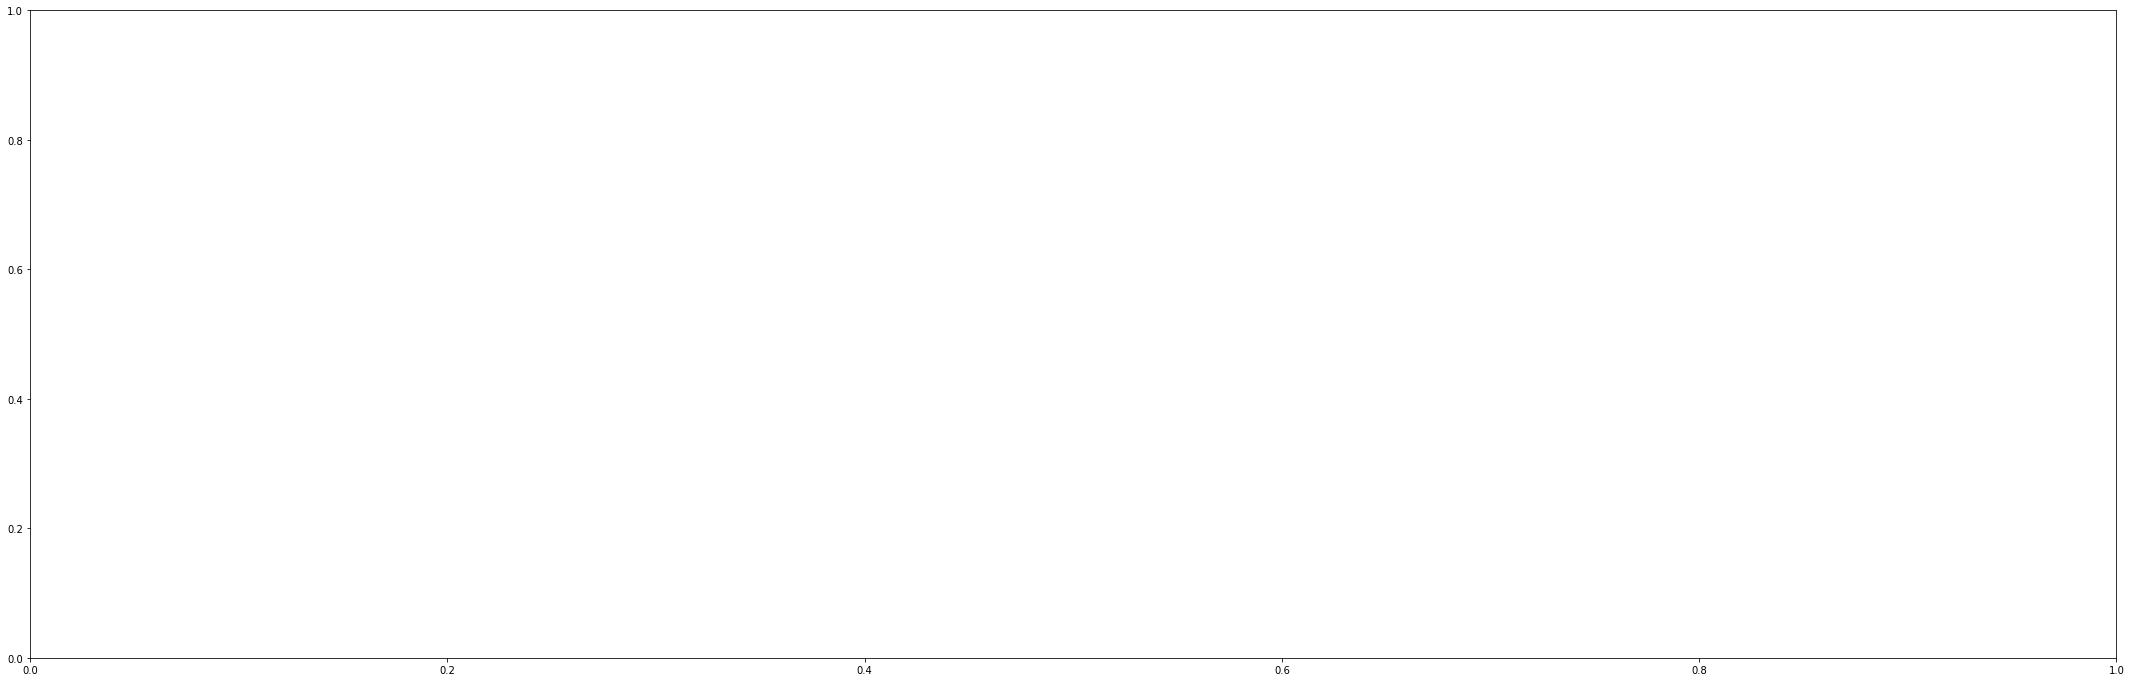

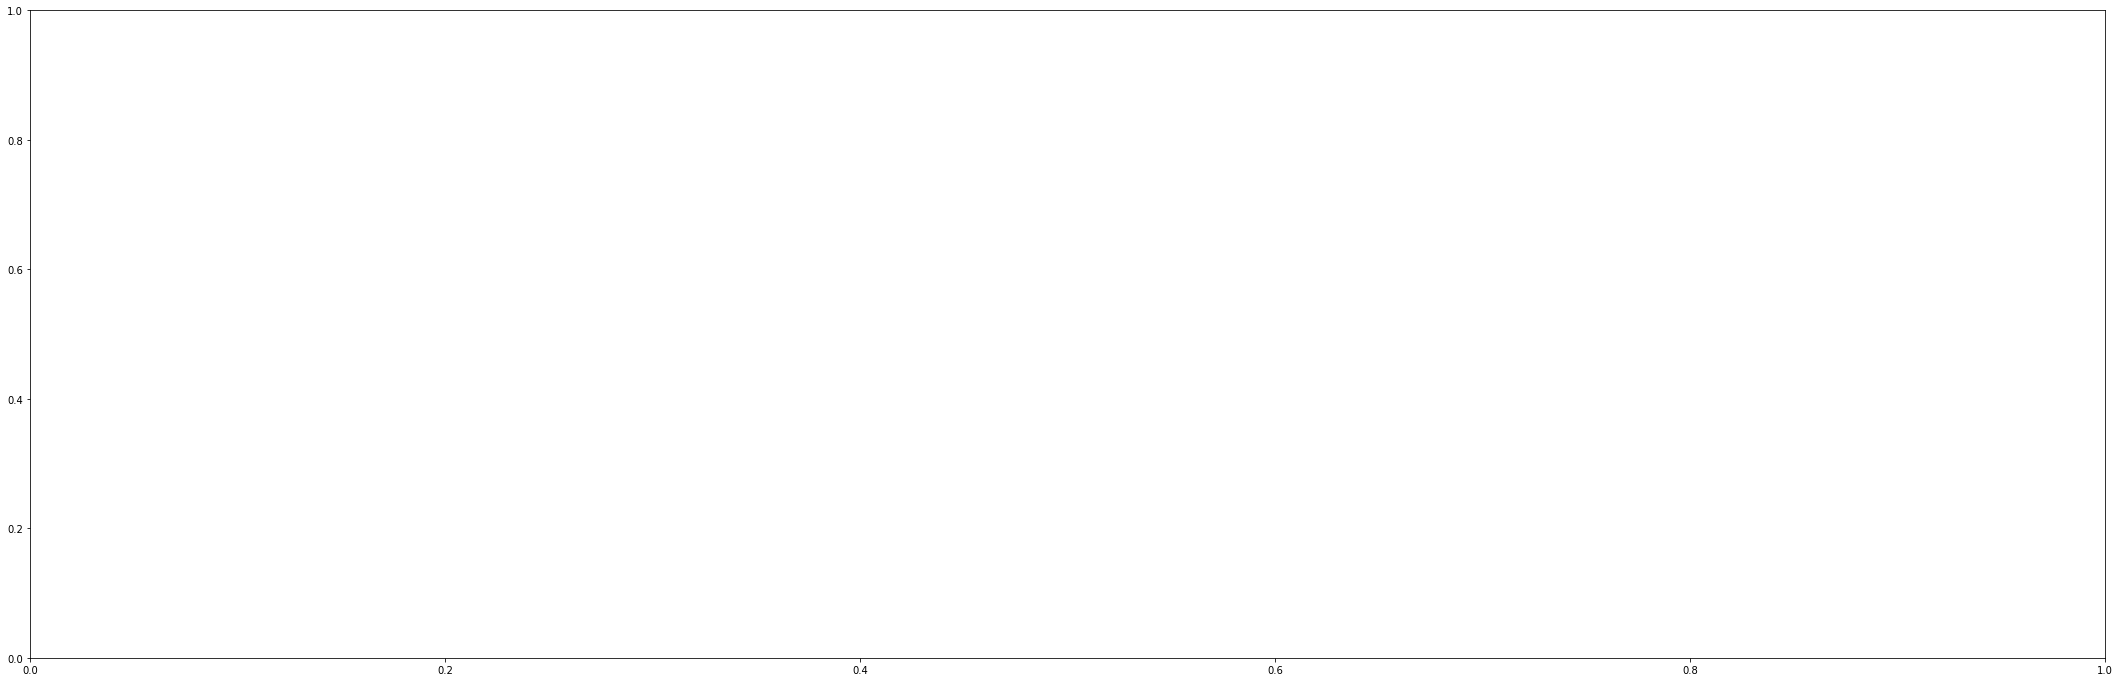

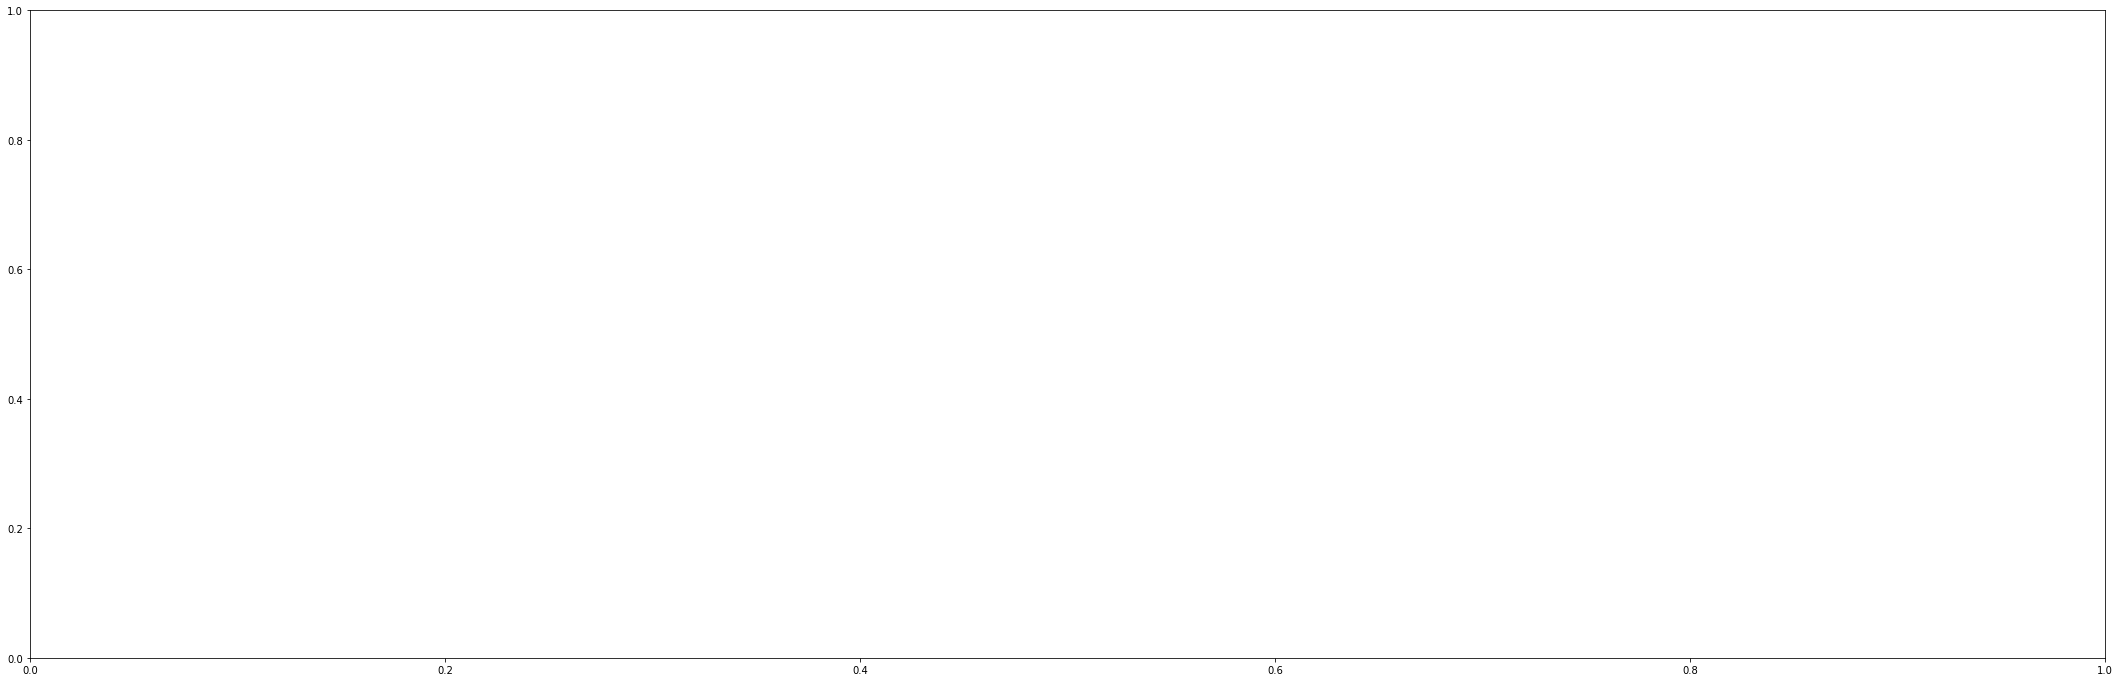

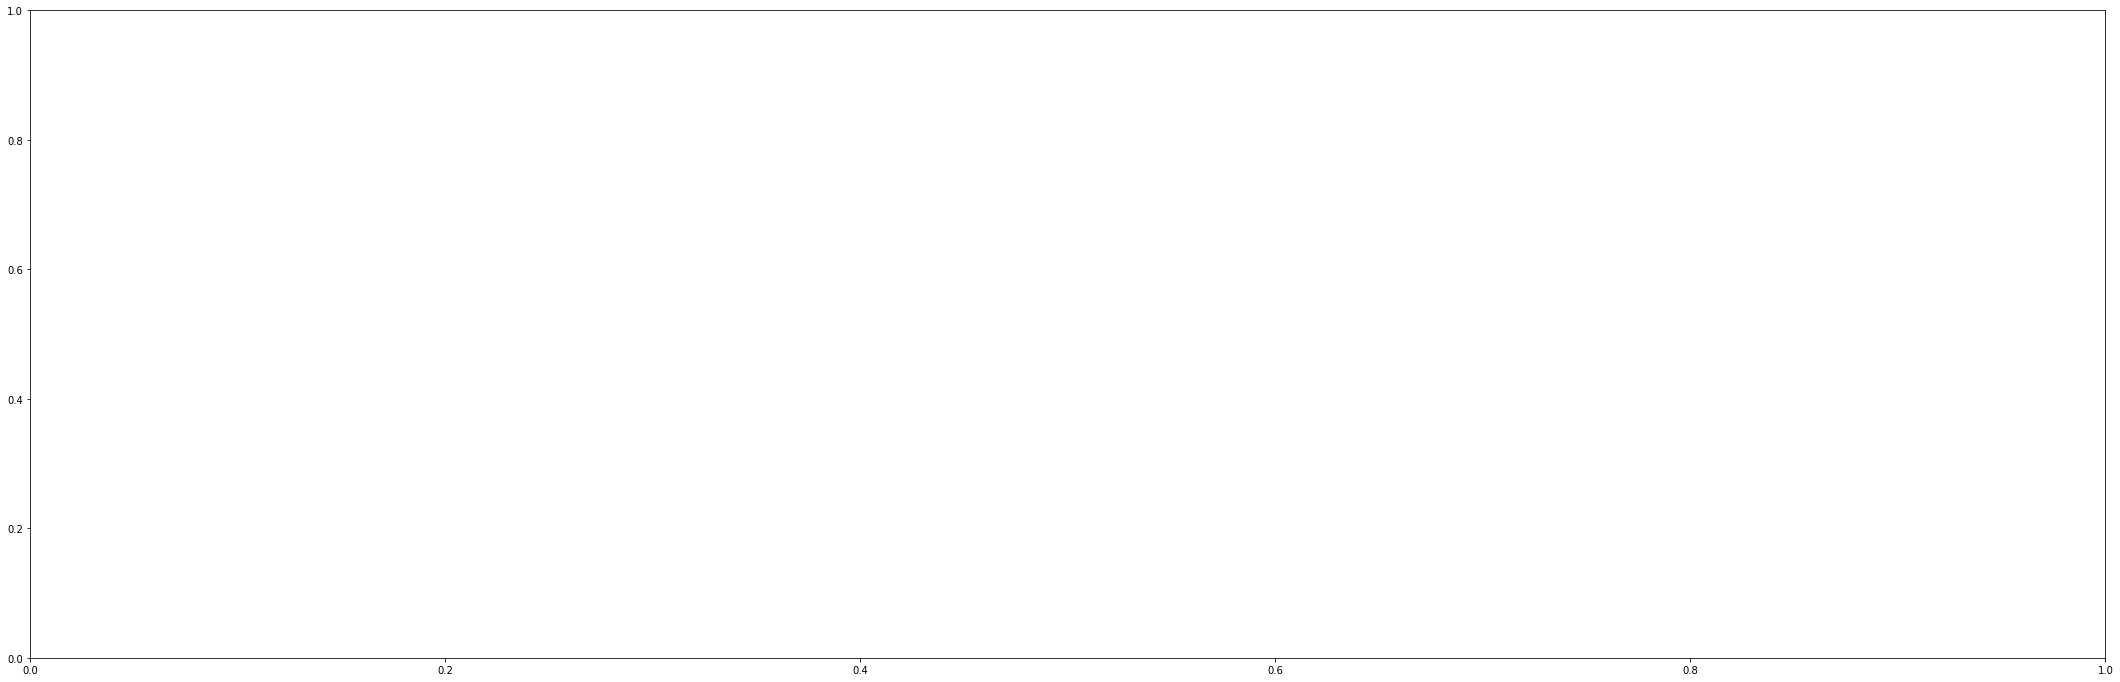

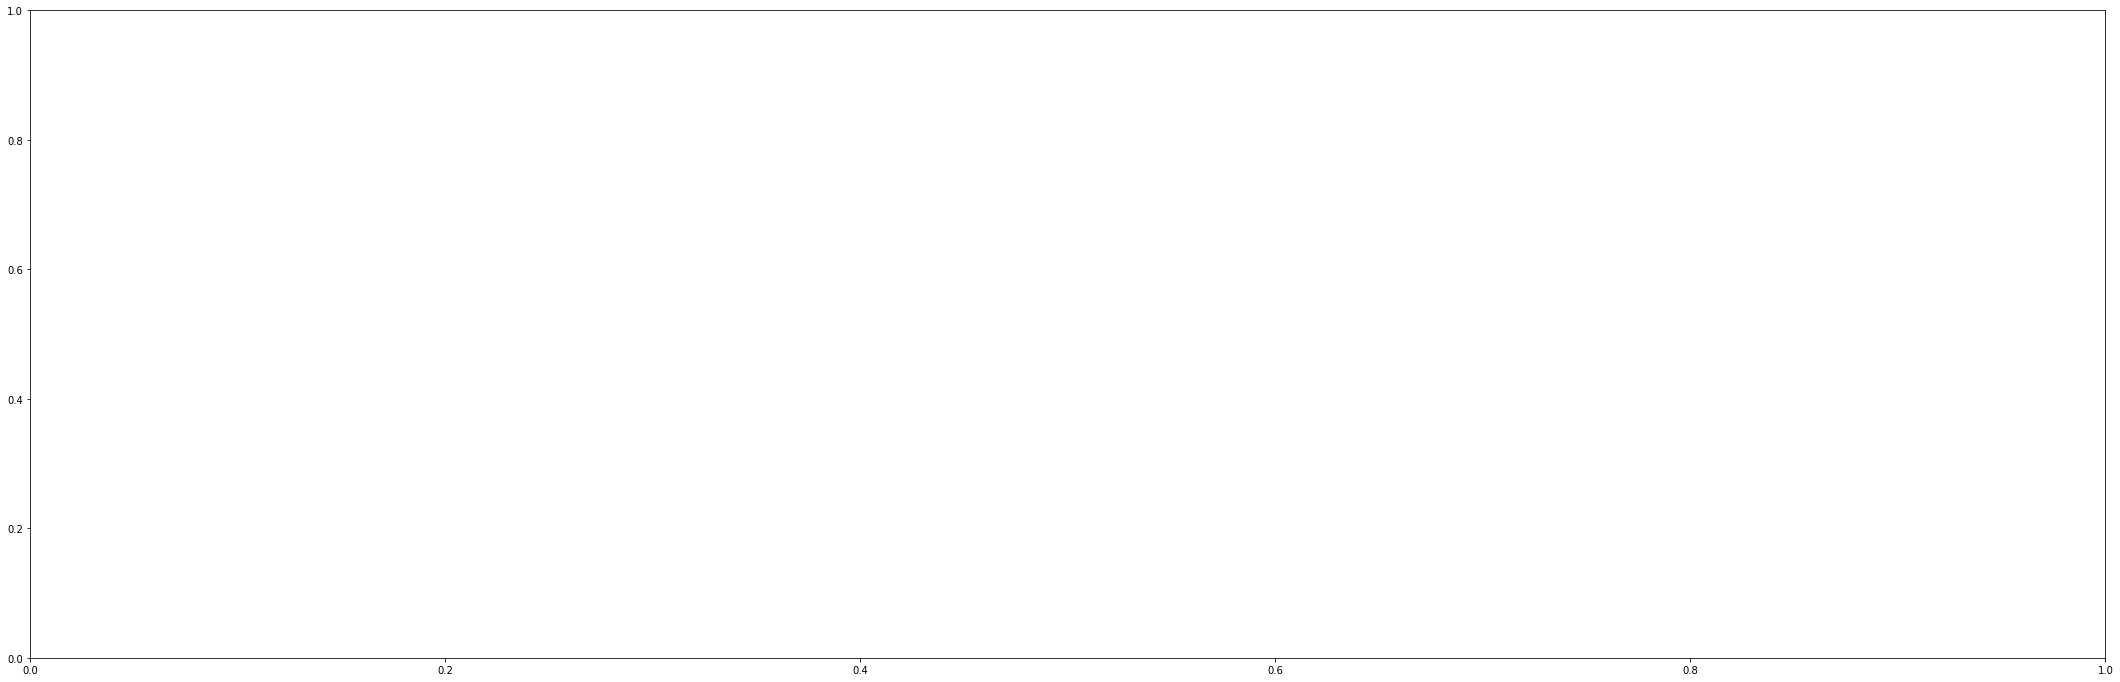

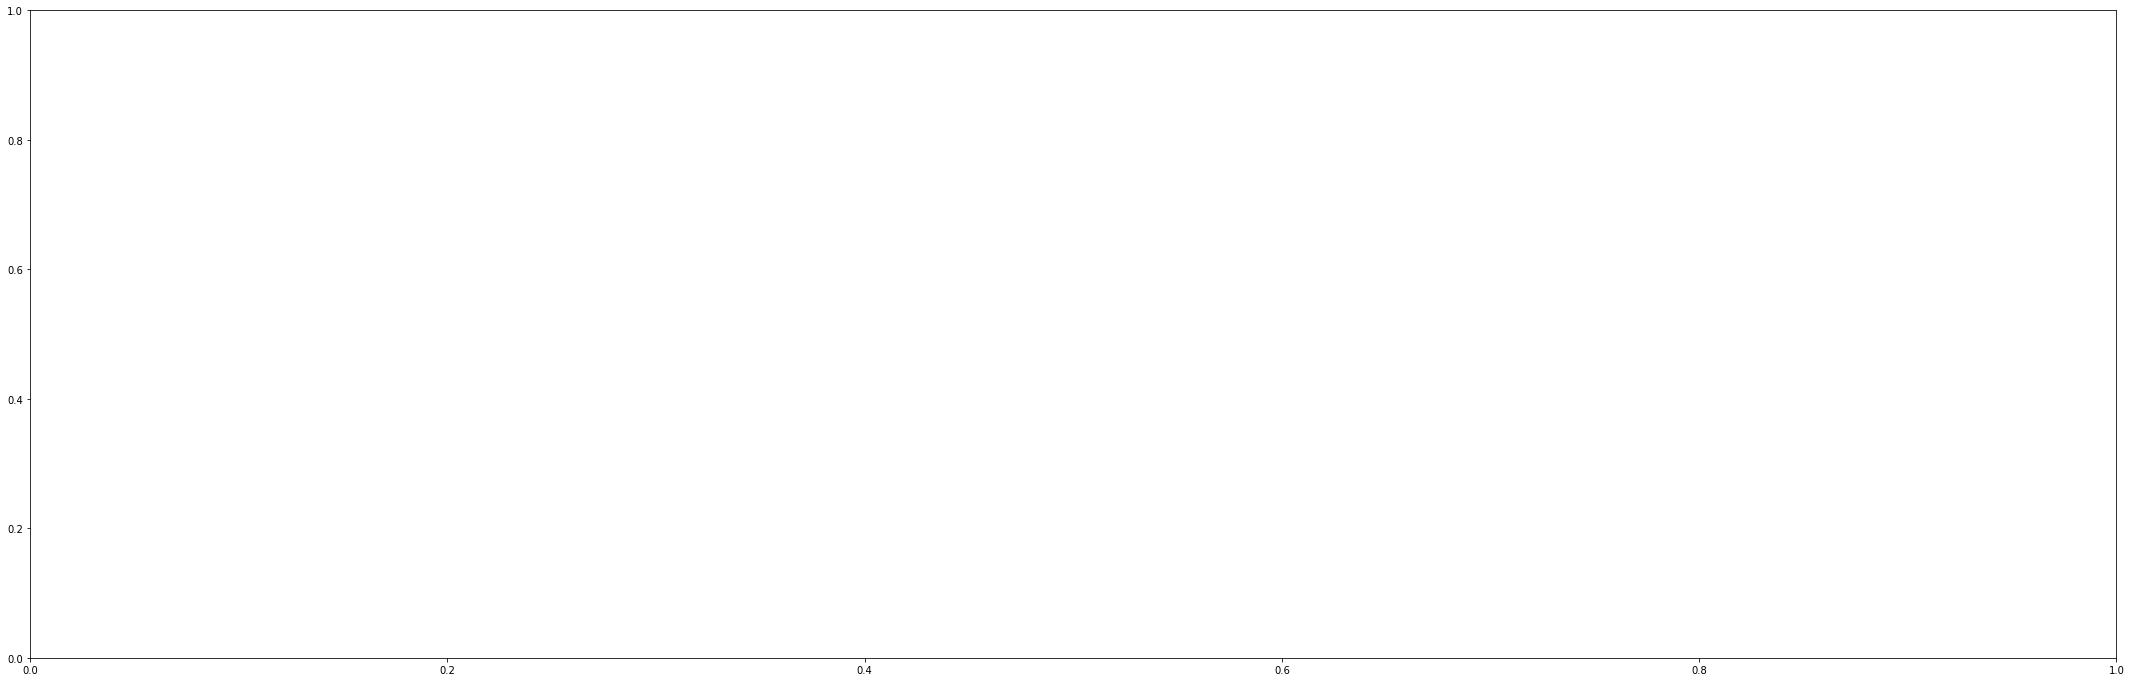

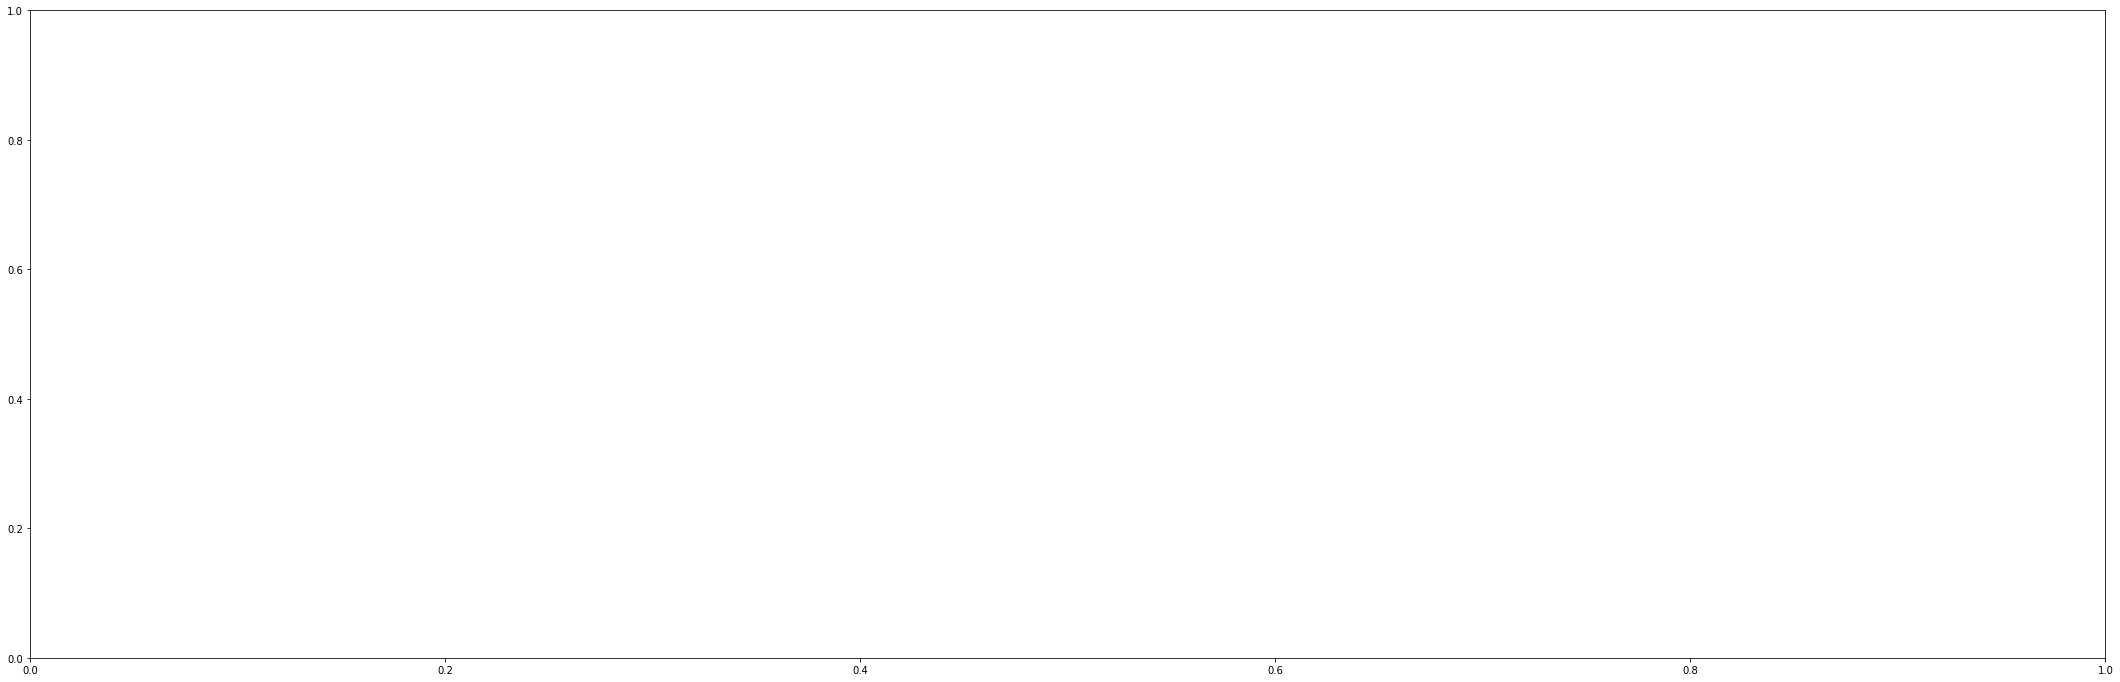

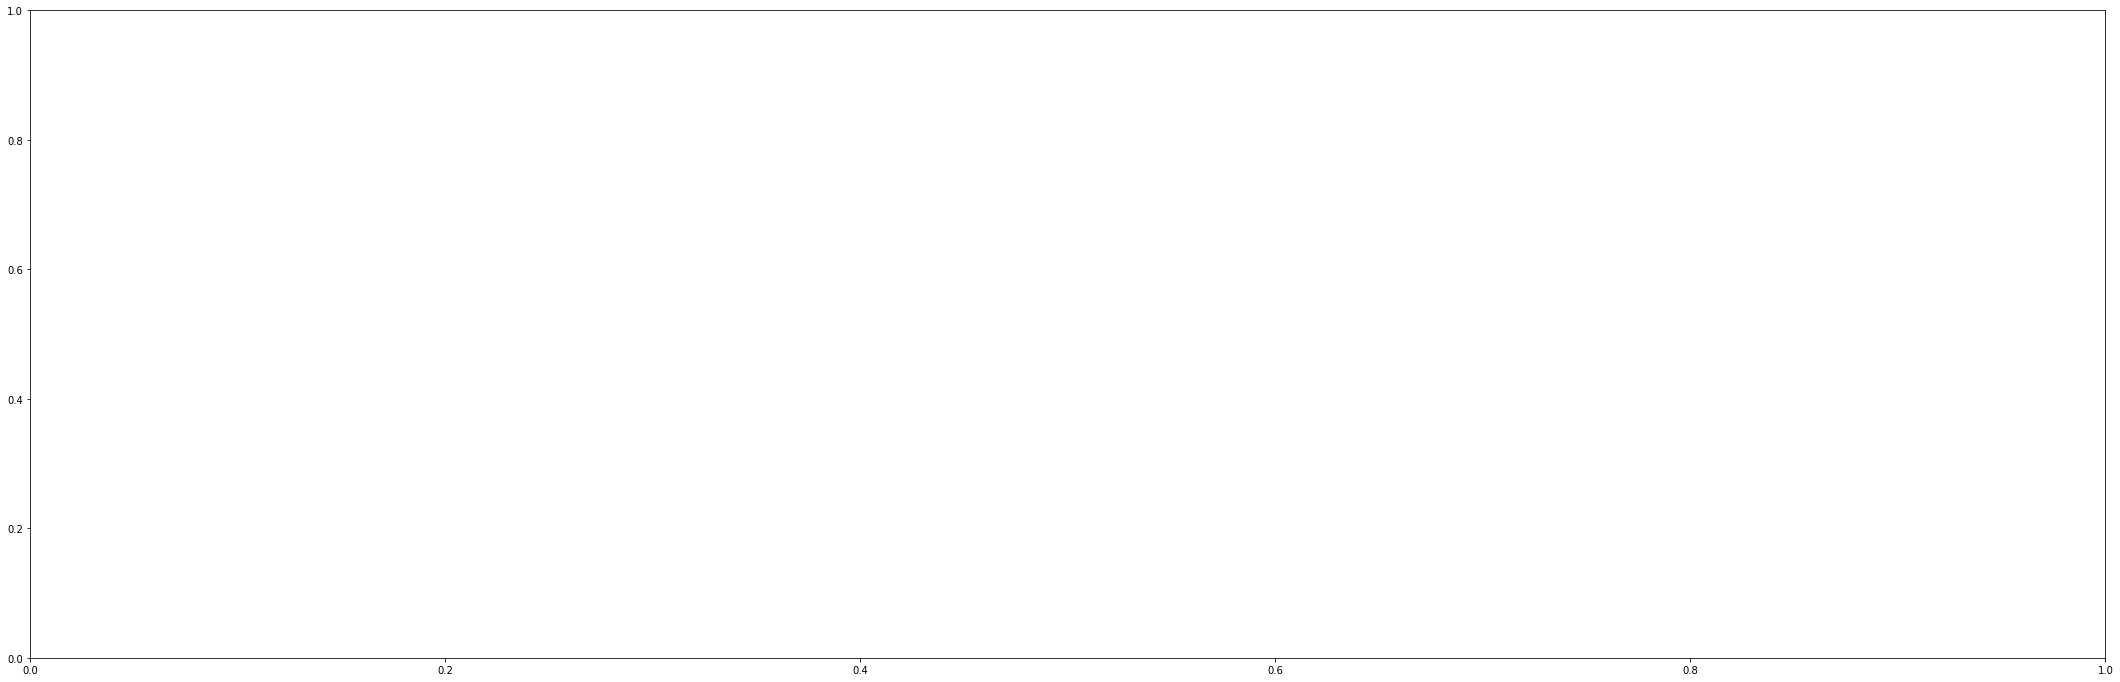

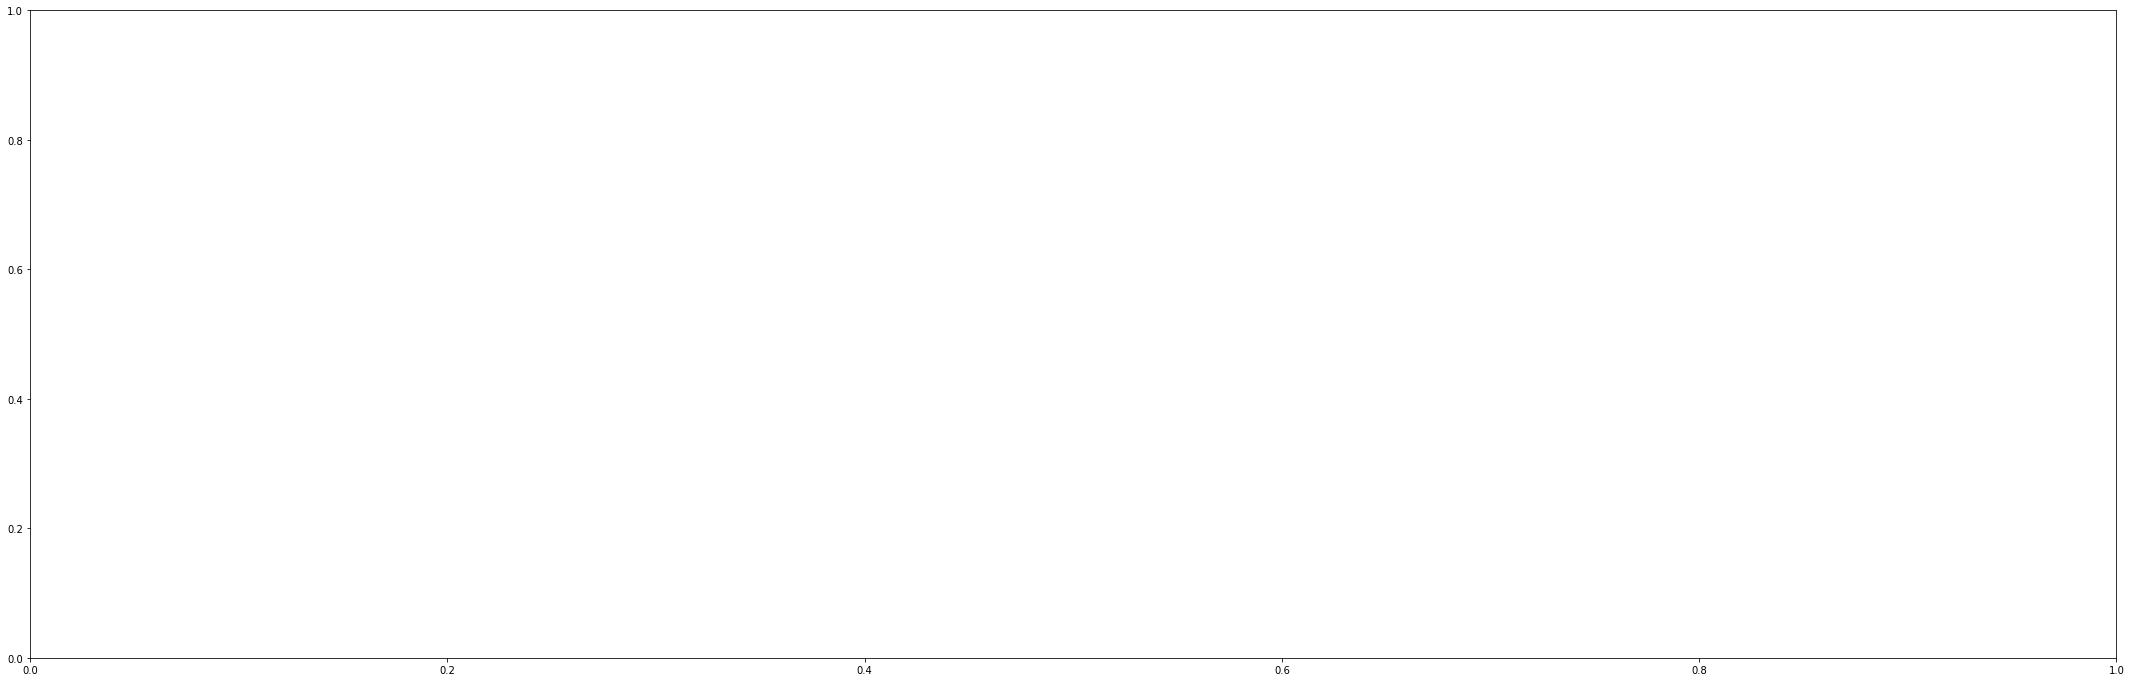

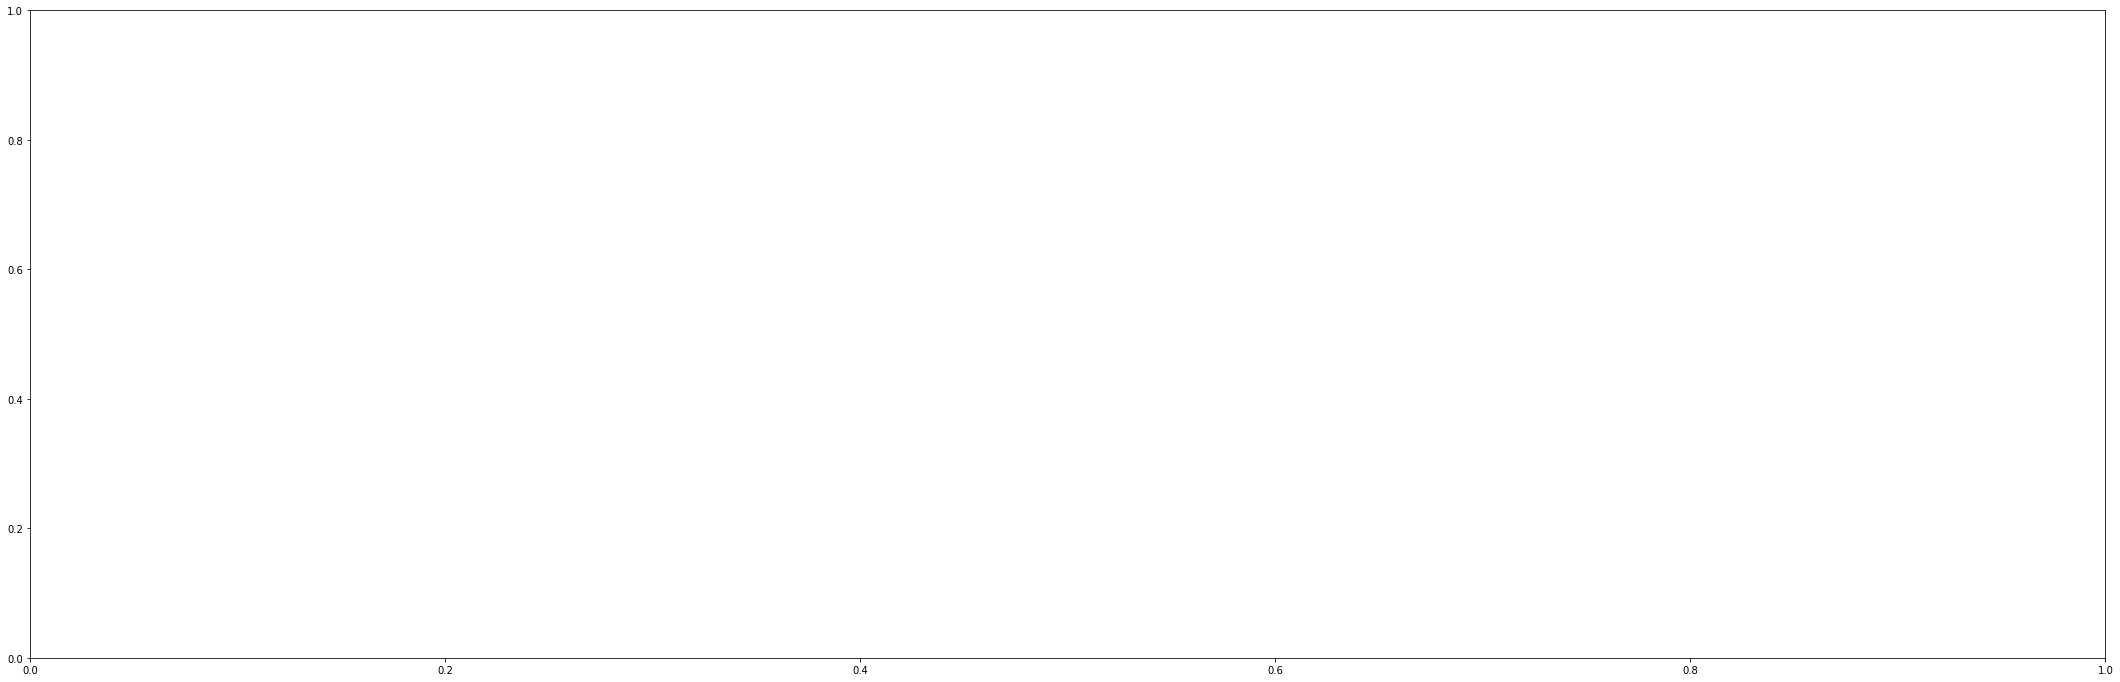

In [26]:
# run for all CAM gene families
for i in cam["gene_abbr"].unique():
    plot_genefam(i)
    plt.clf()
    plt.cla()

## Plot certain gene families with the parents and all three physiological categories

In [27]:
# load parental TPM
yatpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_reanalysis_30-Jun-2025/TPM/Yalo_TPM_withmd_July2025.txt",
                    sep="\t",header="infer")
yftpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_reanalysis_30-Jun-2025/TPM/YfilH1_TPM_withmd_July2025.txt",
                   sep="\t",header="infer")

In [28]:
def plot_profile_parental(fam,cpdf,axc,a,tf,titletext="Gene Family: ",log=False):
    # where axc=either a single value or a tuple
    t = np.arange(0,25)
    xthresh = 12
    
    # convert to logTPM if log=True
    if log==True:
        cpdf["logTPM"] = np.log1p(cpdf["TPM"])
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="logTPM",hue="treat")
    else:
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="TPM",hue="treat")
    
    a[axc].fill_between(t,0,1,where=t>=xthresh,color="gray",alpha=0.3,transform=a[axc].get_xaxis_transform())
    
    a[axc].set_xlim(0,24)
    a[axc].tick_params(axis="both",which="major",labelsize=16)
    a[axc].set_xticks(ticks=list(cpdf["ZT"].unique()))
    a[axc].set_xlabel("")
    a[axc].set_ylabel("TPM from uniquely mapped reads",fontsize=16)
    a[axc].set_title(titletext+fam,fontsize=tf)

In [47]:
def plot_genefam_withparents(genefam,d):
    # get parental plotting TPM
    yaplot = plottpm_genefamily(yatpm,genefam,sg=False)
    yfplot = plottpm_genefamily(yftpm,genefam,sg=False)
    
    # get plotting TPM (Y. gloriosa)
    gftpm = plottpm_genefamily(zttpm,genefam)
    gftpm = rename_camgenes(gftpm,genefam)
    
    # subset data by physiology
    c3 = gftpm[gftpm["CAM physiology"]=="C3"]
    c3gt = len(c3["genotype"].unique())
    pfc = gftpm[gftpm["CAM physiology"]=="possible_fac_CAM"]
    pfcgt = len(pfc["genotype"].unique())
    fc = gftpm[gftpm["CAM physiology"]=="facultative_CAM"]
    fcgt = len(fc["genotype"].unique())
    
    fig, ax = plt.subplots(nrows=1,ncols=5,figsize=(25,5),sharey=True)
    plot_profile_parental("Y. filamentosa (C3 parent)",yfplot,0,ax,26,"")
    plot_profile("C3 genotypes (n="+str(c3gt)+")",c3,1,ax,26,"")
    plot_profile("possibly facultative CAM genotypes (n="+str(pfcgt)+")",pfc,2,ax,16,"")
    plot_profile("facultative CAM genotypes (n="+str(fcgt)+")",fc,3,ax,18,"")
    plot_profile_parental("Y. aloifolia (CAM parent)",yaplot,4,ax,26,"")
    
    ylims = [a.get_ylim()[1] for a in ax]
    ymax = max(ylims)
    for a in ax:
        a.set_ylim(0, ymax)
        
    plt.suptitle(genefam,fontsize=30)

    fig.tight_layout()

    plt.savefig(os.path.join(d,"allgt_withparents_"+genefam+"_profiles_byphys.png"),dpi=200,bbox_inches="tight")
    plt.savefig(os.path.join(d,"allgt_withparents_"+genefam+"_profiles_byphys.pdf"),dpi=200,bbox_inches="tight")
    plt.savefig(os.path.join(d,"allgt_withparents_"+genefam+"_profiles_byphys.svg"),dpi=200,bbox_inches="tight")

In [31]:
d = "./camfamily_profiles_withparents"

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


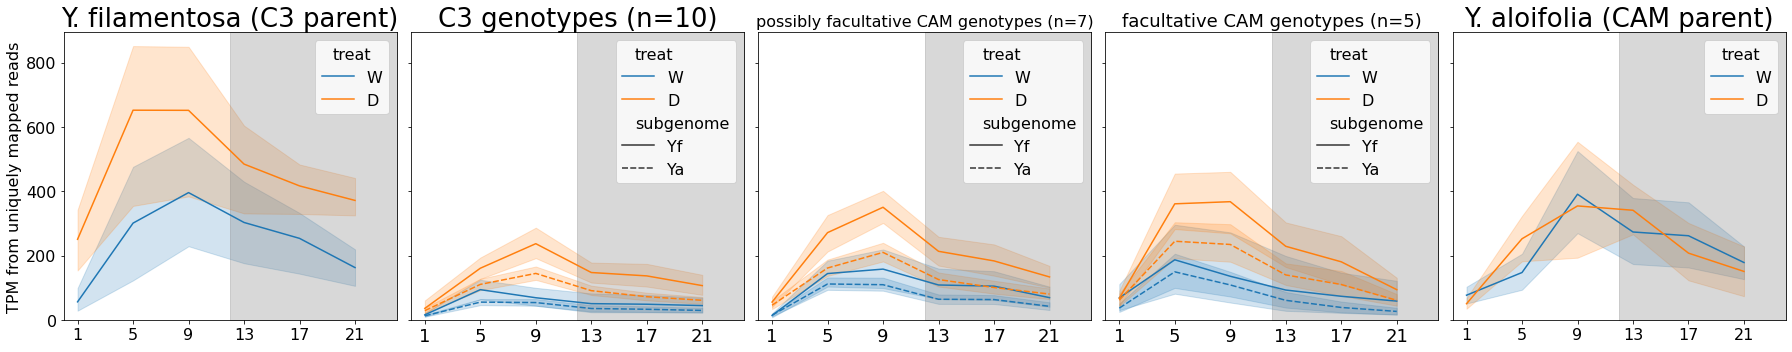

In [42]:
plot_genefam_withparents("BPPC",d)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


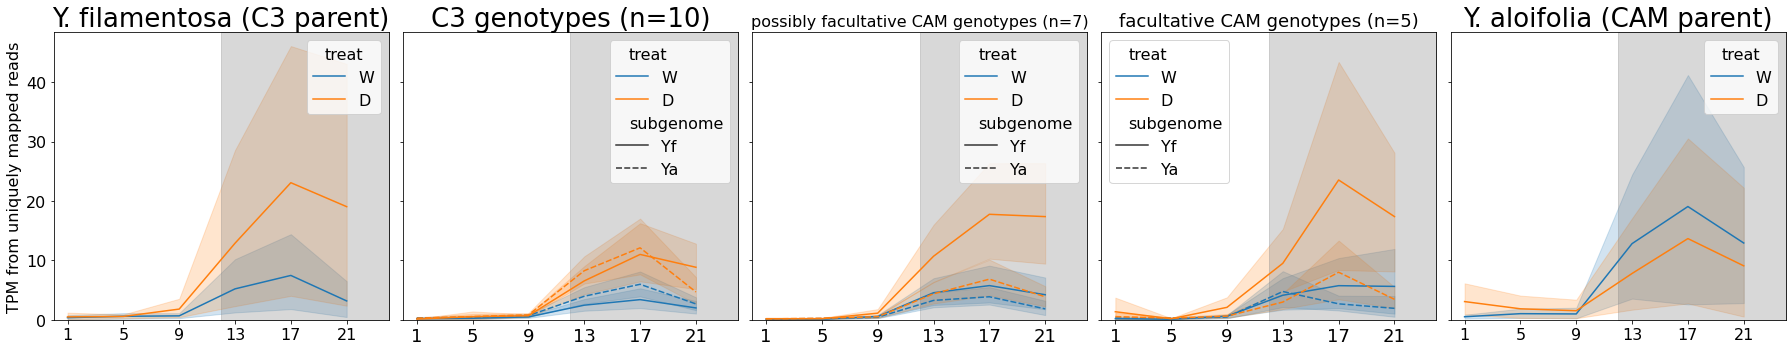

In [43]:
plot_genefam_withparents("PPCK",d)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


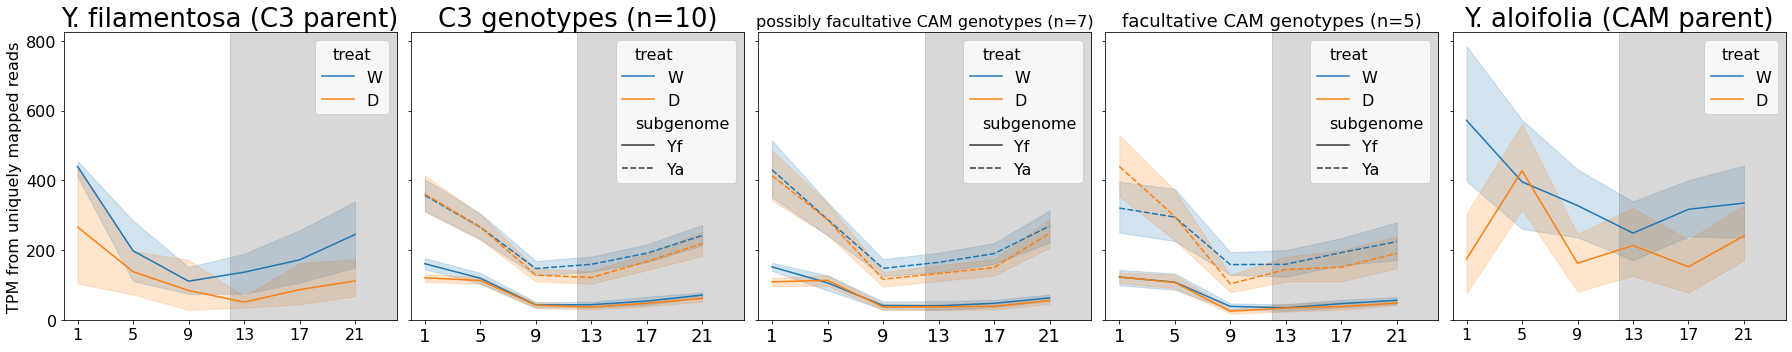

In [44]:
plot_genefam_withparents("PPDK",d)

In [48]:
# well, let's just plot all of them
for i in cam["gene_abbr"].unique():
    plot_genefam_withparents(i,d)
    plt.cla()
    plt.clf()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

<Figure size 1800x360 with 0 Axes>

<Figure size 1800x360 with 0 Axes>

<Figure size 1800x360 with 0 Axes>

<Figure size 1800x360 with 0 Axes>

...

<Figure size 1800x360 with 0 Axes>

<Figure size 1800x360 with 0 Axes>

<Figure size 1800x360 with 0 Axes>

<Figure size 1800x360 with 0 Axes>

<Figure size 1800x360 with 0 Axes>